In [1]:
print('debug')

debug


In [2]:
import gc
import json
import sys
import warnings
import os 
from pathlib import Path
from typing import Dict, Generator, List, Tuple
import numpy as np
import pandas as pd
import pyarrow as pa
import lightgbm as lgb
from pandas.api.types import CategoricalDtype
from pandas.api.types import CategoricalDtype
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import log_loss, accuracy_score
from scipy.stats import poisson, spearmanr
import warnings
import gc
import json
from ngboost import NGBRegressor
from ngboost.distns import Poisson as NGBPoisson
from ngboost.scores import LogScore, CRPScore
from lightgbmlss.model import LightGBMLSS
from lightgbmlss.distributions.Poisson import Poisson as LGBMLSSPoisson
from lightgbmlss.distributions.NegativeBinomial import NegativeBinomial
from typing import List, Union, Optional
from sklearn.base import BaseEstimator
from scipy.stats import nbinom, poisson

# Visualización
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ============================================================
# Configuration
# ============================================================
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

# ============================================================
# Project paths
# ============================================================
NOTEBOOK = "goals"
PROJECT_ROOT = Path.cwd().parents[2]
sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
CONFIG_PATH = PROJECT_ROOT / "configs" / f"{NOTEBOOK}"
# ============================================================
# Project modules
# ============================================================
from src.config.config import load_target_config

from src.utils.utils import (
      split_data,
      clean_key_missing,
      prepare_data_for_training,
      align_frame_to_reference,
      assert_same_categorical_schema,
      categorical_columns,
  )

from src.preprocessing.preprocessing import (
    corregir_marcadores_90,
    preprocessing_1x2_extra_time_filter,
    clean_dataset,
)

# Pipeline de distribucion
  # =============================================================================
from src.config.config import load_target_config

from src.metrics.distribution_metrics import (
    calculate_rps,
    calculate_nll,
    calculate_ece_by_threshold,
    evaluate_distribution_model,
    evaluate_from_config,
    total_pmf,
)

from src.training.distribution_models import (
    MODEL_NAMES,
    train_and_predict,
    predict_params,
    clip_params,
)

from src.training.distribution_cv import (
    build_component_data,
    compare_models,
    evaluate_on_validation,
    likelihood_ratio_test,
)

from src.hypertunning.distribution_tuning import run_tuning, tune_and_save

from src.evaluation.persistence import (
    save_evaluation,
    save_metrics,
    save_best_params,
    load_best_params,
)

from src.error_analysis.distribution_error_analysis import DistributionErrorAnalyzer

from src.utils.utils import save_feature_datasets
# ============================================================
# Experiment configuration
# ============================================================
TRAIN_MODE = True

COMP_TYPE = "clubs"

DATA_PATH = DATA_DIR / COMP_TYPE
RANDOM_STATE = 67
FEATURE_SELECTION_DIR = OUTPUTS_DIR / COMP_TYPE / "feature_selection_subset"
METRICS_DIR = OUTPUTS_DIR / COMP_TYPE / "model_metrics"
MODELS_DIR = OUTPUTS_DIR / COMP_TYPE / "models" / f"{NOTEBOOK}" 
SUBSET_DIR = OUTPUTS_DIR / COMP_TYPE / "feature_selection_subset" / f"{NOTEBOOK}"

SPLITS = {
    "train": ["2021/2022", "2022/2023", "2023/2024"],
    "val": ["2024/2025"],
    "test": ["2025/2026"],
}

# ============================================================
# Load data
# ============================================================
gc.collect()

df = pd.read_parquet(DATA_PATH / "club_features_dataset.parquet")

# El parquet ya viene preprocesado (ver src/preprocessing/build_dataset.py):
# marcadores a 90', totales recalculados y filas sin marcador descartadas.
df_cleaned = df


c:\Users\javie\OneDrive\Escritorio\ModelosProbabilisticos\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
exclude_list = ["match_datetime_utc", "name", "match_id", "tournament"]

EXCLUDE_COLS, LEAKY_COLS, TARGET_COL = clean_dataset(df_cleaned, ['home_score_90', 'away_score_90'])

df_ready = clean_key_missing(df_cleaned, cols_to_check = ["home_score", "away_score"])

df_train, df_val, df_test = split_data(
    df_ready,
    SPLITS
)

print(f"The shape of the TRAIN DATA IS: {df_train.shape}")
print(f"The shape of the VAL DATA IS: {df_val.shape}")
print(f"The shape of the TEST DATA IS: {df_test.shape}")


X_train, y_train, category_map = prepare_data_for_training(
    df_train,
    EXCLUDE_COLS,
    LEAKY_COLS,
    TARGET_COL,
)

X_val, y_val, _ = prepare_data_for_training(
    df_val,
    EXCLUDE_COLS,
    LEAKY_COLS,
    TARGET_COL,
    category_map=category_map,
)

X_test, y_test, _ = prepare_data_for_training(
    df_test,
    EXCLUDE_COLS,
    LEAKY_COLS,
    TARGET_COL,
    category_map=category_map,
)

print(f"The TRAIN SHAPE IS: {X_train.shape} & {y_train.shape}")
print(f"The VAL SHAPE IS: {X_val.shape} & {y_val.shape}")
print(f"The TEST SHAPE IS: {X_test.shape} & {y_test.shape}")


Removed 1755 rows with missing key odds.
Remaining rows: 12407
The shape of the TRAIN DATA IS: (7442, 1416)
The shape of the VAL DATA IS: (2369, 1416)
The shape of the TEST DATA IS: (2596, 1416)
The TRAIN SHAPE IS: (7442, 1048) & (7442, 2)
The VAL SHAPE IS: (2369, 1048) & (2369, 2)
The TEST SHAPE IS: (2596, 1048) & (2596, 2)


In [6]:
print(f'Mean home: {y_train["home_score_90"].mean()} & variance {y_train["home_score_90"].var()}')
print(f'Mean away: {y_train["away_score_90"].mean()} & variance {y_train["away_score_90"].var()}')
zero_home_ratio = (y_train["home_score_90"] == 0).sum()
zero_away_ratio = (y_train["away_score_90"] == 0).sum()
print(f'El tamaño de la muestra es de: {X_train.shape[0]}')
print(f'The zero ratio on home is: {zero_home_ratio/y_train.shape[0]:.4f} & The zero ratio Away is: {zero_away_ratio/y_train.shape[0]:.4f}')


Mean home: 1.5495834453104005 & variance 1.7860776385808985
Mean away: 1.2770760548239721 & variance 1.45392678066832
El tamaño de la muestra es de: 7442
The zero ratio on home is: 0.2280 & The zero ratio Away is: 0.3006


In [7]:
from src.training.distribution_models import train_model
cfg = load_target_config("goals")

model_home = train_model(
    "LightGBMLSS", "poisson",
    X_train, y_train['home_score_90'], X_val, y_val['home_score_90'],
    params=cfg.model_params("LightGBMLSS"),
    fit_params=cfg.fit_params("LightGBMLSS"),
)

In [8]:
print("Training Away score Model...")
model_away = train_model(
    "LightGBMLSS", "poisson",
    X_train, y_train['away_score_90'], X_val, y_val['away_score_90'],
    params=cfg.model_params("LightGBMLSS"),
    fit_params=cfg.fit_params("LightGBMLSS"),
)

Training Away score Model...


### Baseline

In [9]:
from src.training.distribution_models import train_and_predict

model_home, params_home = train_and_predict(
    "LightGBMLSS", "poisson",
    X_train, y_train["home_score_90"],
    X_val,   y_val["home_score_90"],
    params=cfg.model_params("LightGBMLSS"),
    fit_params=cfg.fit_params("LightGBMLSS"),
    guards=cfg.numeric_guards,
)

model_away, params_away = train_and_predict(
    "LightGBMLSS", "poisson",
    X_train, y_train["away_score_90"],
    X_val,   y_val["away_score_90"],
    params=cfg.model_params("LightGBMLSS"),
    fit_params=cfg.fit_params("LightGBMLSS"),
    guards=cfg.numeric_guards,
)

from src.metrics.distribution_metrics import evaluate_from_config
from src.evaluation.persistence import save_evaluation

results = evaluate_from_config(
    y_true={
        "home": y_val["home_score_90"].values,
        "away": y_val["away_score_90"].values,
    },
    params={"home": params_home, "away": params_away},
    config=cfg,
    family="poisson",
    label="Baseline Poisson (LightGBMLSS)",
    verbose=True,
)

save_evaluation(
      results,
      name="baseline_poisson_validation_results",
      config=cfg,
      metadata={
          "models": {"home": "LightGBMLSS", "away": "LightGBMLSS"},
          "split": "validation",
          "n_features": {"home": X_train.shape[1],
                         "away": X_train.shape[1]},
      },
  )


  FULL EVALUATION - Baseline Poisson (LightGBMLSS) [poisson]

--------------------------------------------------
  RPS Report - Baseline Poisson (LightGBMLSS) | home [poisson]
--------------------------------------------------
  N observaciones : 2369
  RPS mean        : 0.64012   <- principal
  RPS std         : 0.56061
  RPS median      : 0.46742
  RPS p95         : 1.74161   <- cola
--------------------------------------------------

--------------------------------------------------
  RPS Report - Baseline Poisson (LightGBMLSS) | away [poisson]
--------------------------------------------------
  N observaciones : 2369
  RPS mean        : 0.62582   <- principal
  RPS std         : 0.57516
  RPS median      : 0.40927
  RPS p95         : 1.79750   <- cola
--------------------------------------------------

--------------------------------------------------
  NLL Report - Baseline Poisson (LightGBMLSS) | home [poisson]
--------------------------------------------------
  N observacio

WindowsPath('C:/Users/javie/OneDrive/Escritorio/ModelosProbabilisticos/EnvOficial/outputs/clubs/model_metrics/goals/baseline_poisson_validation_results.json')

### Feature selection Process

In [ ]:
from src.config.config import load_config
from src.feature_selection.poisson_feature_selection import (
    PoissonSelectionConfig, run_poisson_feature_selection,
)

cfg = load_config(CONFIG_PATH / "goals_config.yaml")
sel_cfg = PoissonSelectionConfig.from_model_config(cfg)   

home_final_features, Xtr_home, Xvl_home, Xte_home, report_home = run_poisson_feature_selection(
    X_train=X_train, X_val=X_val, X_test=X_test,
    y_train=y_train["home_score_90"],
    y_val=y_val["home_score_90"],
    target_name="home_score_90",
    cfg=sel_cfg,
    max_k=cfg.target.max_k,
)


  [CHECK] El índice no es DatetimeIndex; no se puede verificar el
          orden cronológico automáticamente. Confirmá a mano que
          X_train está ordenado por fecha ASCENDENTE.
  POISSON TEMPORAL FEATURE SELECTION — target = home_score_90
  Train: (7442, 1048)   Val: (2369, 1048)   Test: (2596, 1048)
  Target: media = 1.5496, var = 1.7858, var/media = 1.152
  Ratio filas/features: 7.1:1
  Semilla: 67   Workers: 8

  STEP 0 — Sparsity Filter  (moda > 95%, NaN > 95%)
  Features entrada    : 1048
  Cuasi-constantes    : 37
  Features restantes  : 1011

  Categóricas declaradas: 57

  [AUDIT] 3 categóricas con niveles no vistos (>1%):
                     feature  n_levels_train  val_extra_nan_rate  test_extra_nan_rate
    home_roll_5_sp_goals_for              17              0.0004               0.0297
home_roll_5_sp_goals_against              18              0.0008               0.0293
away_roll_5_sp_goals_against              18              0.0013               0.0270

  STEP 0

### Feature Selection Process END

In [11]:
home_final_features

['diff_roll_5_team_squad_value_eur',
 'home_total_shots_elo_prob',
 'h2h_pct_over_3_5_goals_last_5',
 'inter_elo_netcount',
 'away_roll_5_line_market_val_DEF',
 'home_elo_opponent_vs_league',
 'diff_roll_5_line_market_val_ATT',
 'home_team_avg_goals_last_20',
 'diff_pct_team_scores_first_goal_last_20',
 'home_pct_team_shots_over_17_5_last_20',
 'home_team_avg_xg_last_20',
 'diff_team_avg_possession_last_10',
 'away_team_avg_conceded_last_20',
 'away_total_neg',
 'away_pct_team_games_shots_over_30_5_last_20',
 'diff_team_clean_sheet_pct_last_20']

In [13]:
print(f"Inicio               : {report_home.n_start}")
print(f"Post Sparsity (S0)   : {report_home.n_after_sparsity}")
print(f"Post MI (S1)         : {report_home.n_after_mi}")        
print(f"Post Correlación (S2): {report_home.n_after_corr}")      
print(f"Post Permutación (S3): {report_home.n_after_shuffle}")   
print(f"Post Estabilidad (S4): {report_home.n_after_stability}")

Inicio               : 1048
Post Sparsity (S0)   : 1011
Post MI (S1)         : 410
Post Correlación (S2): 191
Post Permutación (S3): 16
Post Estabilidad (S4): 16


In [14]:
away_final_features, Xtr_away, Xvl_away, Xte_away, report_away = run_poisson_feature_selection(
    X_train=X_train, X_val=X_val, X_test=X_test,
    y_train=y_train["away_score_90"],
    y_val=y_val["away_score_90"],
    target_name="away_score_90",
    cfg=CONFIG,
)

  [CHECK] El índice no es DatetimeIndex; no se puede verificar el
          orden cronológico automáticamente. Confirmá a mano que
          X_train está ordenado por fecha ASCENDENTE.
  POISSON TEMPORAL FEATURE SELECTION — target = away_score_90
  Train: (7442, 1048)   Val: (2369, 1048)   Test: (2596, 1048)
  Target: media = 1.2771, var = 1.4537, var/media = 1.138
  Ratio filas/features: 7.1:1
  Semilla: 67   Workers: 8

  STEP 0 — Sparsity Filter  (moda > 95%, NaN > 95%)
  Features entrada    : 1048
  Cuasi-constantes    : 37
  Features restantes  : 1011

  Categóricas declaradas: 57

  [AUDIT] 3 categóricas con niveles no vistos (>1%):
                     feature  n_levels_train  val_extra_nan_rate  test_extra_nan_rate
    home_roll_5_sp_goals_for              17              0.0004               0.0297
home_roll_5_sp_goals_against              18              0.0008               0.0293
away_roll_5_sp_goals_against              18              0.0013               0.0270

  STEP 0

In [16]:
away_final_features

['diff_roll_5_team_squad_value_eur',
 'away_team_avg_dribbles_last_20',
 'home_elo_rating',
 'away_team_avg_goals_last_20',
 'home_net_count',
 'home_total_shots_elo_prob',
 'away_team_avg_shots_last_10',
 'away_roll_5_line_market_val_ATT',
 'home_team_avg_xga_last_20',
 'home_elo_prob_win',
 'home_pct_sot_last_10_sot_Foot',
 'away_pct_team_shots_over_15_5_last_20',
 'diff_roll_5_line_market_val_ATT',
 'h2h_home_avg_goal_diff_last_5',
 'diff_pct_team_shots_over_15_5_last_20',
 'home_roll_5_line_market_val_ATT']

In [15]:
print(f"Inicio               : {report_away.n_start}")
print(f"Post Sparsity (S0)   : {report_away.n_after_sparsity}")
print(f"Post MI (S1)         : {report_away.n_after_mi}")        
print(f"Post Correlación (S2): {report_away.n_after_corr}")      
print(f"Post Permutación (S3): {report_away.n_after_shuffle}")   
print(f"Post Estabilidad (S4): {report_away.n_after_stability}")

Inicio               : 1048
Post Sparsity (S0)   : 1011
Post MI (S1)         : 368
Post Correlación (S2): 188
Post Permutación (S3): 16
Post Estabilidad (S4): 16


In [17]:
print(f"\nFeatures HOME: {home_final_features}")
print(f"Features AWAY: {away_final_features}")


Features HOME: ['diff_roll_5_team_squad_value_eur', 'home_total_shots_elo_prob', 'h2h_pct_over_3_5_goals_last_5', 'inter_elo_netcount', 'away_roll_5_line_market_val_DEF', 'home_elo_opponent_vs_league', 'diff_roll_5_line_market_val_ATT', 'home_team_avg_goals_last_20', 'diff_pct_team_scores_first_goal_last_20', 'home_pct_team_shots_over_17_5_last_20', 'home_team_avg_xg_last_20', 'diff_team_avg_possession_last_10', 'away_team_avg_conceded_last_20', 'away_total_neg', 'away_pct_team_games_shots_over_30_5_last_20', 'diff_team_clean_sheet_pct_last_20']
Features AWAY: ['diff_roll_5_team_squad_value_eur', 'away_team_avg_dribbles_last_20', 'home_elo_rating', 'away_team_avg_goals_last_20', 'home_net_count', 'home_total_shots_elo_prob', 'away_team_avg_shots_last_10', 'away_roll_5_line_market_val_ATT', 'home_team_avg_xga_last_20', 'home_elo_prob_win', 'home_pct_sot_last_10_sot_Foot', 'away_pct_team_shots_over_15_5_last_20', 'diff_roll_5_line_market_val_ATT', 'h2h_home_avg_goal_diff_last_5', 'diff_

In [18]:
from src.config.config import load_target_config
from src.training.distribution_cv import evaluate_on_validation
from src.evaluation.persistence import save_evaluation

cfg = load_target_config("goals")

X_tr = {"home": X_train, "away": X_train}
y_tr = {"home": y_train["home_score_90"], "away": y_train["away_score_90"]}
X_va = {"home": X_val,   "away": X_val}
y_va = {"home": y_val["home_score_90"],   "away": y_val["away_score_90"]}
feats = {"home": home_final_features, "away": away_final_features}

summary, results = evaluate_on_validation(
    cfg, X_tr, y_tr, X_va, y_va, feats,
    models=["LightGBMLSS"],
    family="poisson",
    verbose=True,
)

save_evaluation(
    results["LightGBMLSS"],
    "feature_selected_validation_baseline_results",
    cfg,
    metadata={"split": "2024/2025", "label": "LightGBMLSS Baseline"},
)

--- Entrenando LightGBMLSS | home [poisson] ---
--- Entrenando LightGBMLSS | away [poisson] ---

  FULL EVALUATION - LightGBMLSS | poisson [poisson]

--------------------------------------------------
  RPS Report - LightGBMLSS | poisson | home [poisson]
--------------------------------------------------
  N observaciones : 2369
  RPS mean        : 0.64136   <- principal
  RPS std         : 0.53874
  RPS median      : 0.47362
  RPS p95         : 1.64635   <- cola
--------------------------------------------------

--------------------------------------------------
  RPS Report - LightGBMLSS | poisson | away [poisson]
--------------------------------------------------
  N observaciones : 2369
  RPS mean        : 0.62103   <- principal
  RPS std         : 0.55358
  RPS median      : 0.42814
  RPS p95         : 1.74584   <- cola
--------------------------------------------------

--------------------------------------------------
  NLL Report - LightGBMLSS | poisson | home [poisson]
-----

WindowsPath('C:/Users/javie/OneDrive/Escritorio/ModelosProbabilisticos/EnvOficial/outputs/clubs/model_metrics/goals/feature_selected_validation_baseline_results.json')

In [19]:
import pandas as pd
from pathlib import Path
from typing import List

# Define the Metadata columns you want to keep
METADATA_COLS = [
    'match_datetime_utc',
    'match_id',
    'name',
    'home_score_90',
    'away_score_90',
    'tournament'
]

def prepare_and_save_datasets(
    df: pd.DataFrame,
    home_features: List[str],
    away_features: List[str],
    output_path: Path,
    home_name: str = 'home_score_90_feature_selection.parquet',
    away_name: str = 'away_score_90_feature_selection.parquet'
):
    print("--- Saving Final Datasets ---")

    df = df.copy()

    # Move the SAFETY FIX here to ensure RECENT_FORM_CHECK_IN receives a DataFrame with unique columns
    # 1. SAFETY FIX: Remove any duplicate columns that might have been created
    df = df.loc[:, ~df.columns.duplicated()].copy()


    # The line below was moved up to before RECENT_FORM_CHECK_IN
    # df = df.loc[:, ~df.columns.duplicated()].copy()

    # 2. Ensure Datetime format
    if not pd.api.types.is_datetime64_any_dtype(df['match_datetime_utc']):
        df['match_datetime_utc'] = pd.to_datetime(df['match_datetime_utc'], format='ISO8601', errors='coerce')

    # NOTE: We removed the redundant feature engineering steps here
    # because your `df` already contains all the engineered features!

    print(f"Data Shape before saving: {df.shape}")

    # ==============================================================================
    # 3. SAVE HOME DATASET
    # ==============================================================================
    cols_to_save_home = METADATA_COLS + home_features
    cols_to_save_home = list(dict.fromkeys(cols_to_save_home)) # Remove duplicates

    valid_cols_home = [c for c in cols_to_save_home if c in df.columns]

    missing_home = set(cols_to_save_home) - set(valid_cols_home)
    if missing_home:
        print(f"\n[Home] Note: The following missing features were excluded from parquet: {missing_home}")

    df[valid_cols_home].to_parquet(output_path / home_name, index=False)
    print(f"Saved {home_name} with {len(valid_cols_home)} columns.")

    # ==============================================================================
    # 4. SAVE AWAY DATASET
    # ==============================================================================
    cols_to_save_away = METADATA_COLS + away_features
    cols_to_save_away = list(dict.fromkeys(cols_to_save_away))

    valid_cols_away = [c for c in cols_to_save_away if c in df.columns]

    missing_away = set(cols_to_save_away) - set(valid_cols_away)
    if missing_away:
        print(f"\n[Away] Note: The following missing features were excluded from parquet: {missing_away}")

    df[valid_cols_away].to_parquet(output_path / away_name, index=False)
    print(f"Saved {away_name} with {len(valid_cols_away)} columns.")

# Execute the save function
prepare_and_save_datasets(
    df=df_ready,
    home_features=home_final_features,
    away_features=away_final_features,
    output_path=SUBSET_DIR,
    home_name='home_score_90_feature_selection.parquet',
    away_name='away_score_90_feature_selection.parquet'
)

--- Saving Final Datasets ---
Data Shape before saving: (12407, 1416)
Saved home_score_90_feature_selection.parquet with 22 columns.
Saved away_score_90_feature_selection.parquet with 22 columns.


### Model Creation

In [3]:
TARGET_COLS = ['home_score_90', 'away_score_90']

EXCLUDE_COLS = [
    'match_datetime_utc',
    'match_id',
    'name',
    'tournament'
]

LEAKY_COLS = ['home_score_90', 'away_score_90']

df_home = pd.read_parquet(SUBSET_DIR / 'home_score_90_feature_selection.parquet')
df_away = pd.read_parquet(SUBSET_DIR / 'away_score_90_feature_selection.parquet')

df_train_home, df_val_home, df_test_home = split_data(df_home, SPLITS)
df_train_away, df_val_away, df_test_away = split_data(df_away, SPLITS)

X_train_home, y_train_home, cat_features_home = prepare_data_for_training(df = df_train_home, EXCLUDE_COLS=EXCLUDE_COLS, leaky_cols = None, TARGET_COL=TARGET_COLS, category_map=None)
X_val_home, y_val_home, _ = prepare_data_for_training(df = df_val_home, EXCLUDE_COLS=EXCLUDE_COLS, leaky_cols = None, TARGET_COL=TARGET_COLS, category_map=cat_features_home)
X_test_home, y_test_home, _ = prepare_data_for_training(df = df_test_home, EXCLUDE_COLS=EXCLUDE_COLS, leaky_cols = None, TARGET_COL=TARGET_COLS, category_map=cat_features_home)
print('HOME INFO')
print(f'The TRAIN SHAPE IS: {X_train_home.shape} & {y_train_home.shape}')
print(f'The VAL SHAPE IS: {X_val_home.shape} & {y_val_home.shape}')
print(f'The TEST SHAPE IS: {X_test_home.shape} & {y_test_home.shape}')

print('AWAY INFO')
X_train_away, y_train_away, cat_features_away = prepare_data_for_training(df = df_train_away, EXCLUDE_COLS=EXCLUDE_COLS, leaky_cols = None, TARGET_COL=TARGET_COLS, category_map=None)
X_val_away, y_val_away, _ = prepare_data_for_training(df = df_val_away, EXCLUDE_COLS=EXCLUDE_COLS, leaky_cols = None, TARGET_COL=TARGET_COLS, category_map=cat_features_away)
X_test_away, y_test_away, _ = prepare_data_for_training(df = df_test_away, EXCLUDE_COLS=EXCLUDE_COLS, leaky_cols = None, TARGET_COL=TARGET_COLS, category_map=cat_features_away)
print(f'The TRAIN SHAPE IS: {X_train_away.shape} & {y_train_away.shape}')
print(f'The VAL SHAPE IS: {X_val_away.shape} & {y_val_away.shape}')
print(f'The TEST SHAPE IS: {X_test_away.shape} & {y_test_away.shape}')

HOME INFO
The TRAIN SHAPE IS: (7442, 16) & (7442, 2)
The VAL SHAPE IS: (2369, 16) & (2369, 2)
The TEST SHAPE IS: (2596, 16) & (2596, 2)
AWAY INFO
The TRAIN SHAPE IS: (7442, 16) & (7442, 2)
The VAL SHAPE IS: (2369, 16) & (2369, 2)
The TEST SHAPE IS: (2596, 16) & (2596, 2)


In [4]:
from src.config.config import load_target_config
from src.training.distribution_cv import compare_models
from src.evaluation.persistence import save_metrics

cfg = load_target_config("goals")

X     = {"home": X_train_home, "away": X_train_away}
y     = {"home": y_train_home["home_score_90"], "away": y_train_away["away_score_90"]}
feats = {"home": X_train_home.columns.tolist(), "away": X_train_away.columns.tolist()}

comparison = compare_models(cfg, X, y, feats)   # 3 modelos x 2 familias x 2 componentes

print(comparison["summary"].to_string(index=False))
print(comparison["lr_tests"].to_string(index=False))

save_metrics(
    {
        "summary":   comparison["summary"],
        "lr_tests":  comparison["lr_tests"],
        "failures":  comparison["failures"],
    },
    "model_selection_results_validation",
    cfg,
)


  [LightGBMLSS | poisson] TSCV (n_splits=5)...
    Fold 1 - RPS: 0.64729 | NLL: 1.50781
    Fold 2 - RPS: 0.68180 | NLL: 1.55251
    Fold 3 - RPS: 0.65252 | NLL: 1.52509
    Fold 4 - RPS: 0.66360 | NLL: 1.54394
    Fold 5 - RPS: 0.64788 | NLL: 1.52038

  [LightGBMLSS | negbin] TSCV (n_splits=5)...
    Fold 1 - RPS: 1.03823 | NLL: 1.83887
    Fold 2 - RPS: 0.76093 | NLL: 1.66525
    Fold 3 - RPS: 0.71759 | NLL: 1.64884
    Fold 4 - RPS: 1.49453 | NLL: 2.10657
    Fold 5 - RPS: 2.01000 | NLL: 2.37192

  [XGBoostLSS | poisson] TSCV (n_splits=5)...
    Fold 1 - RPS: 0.65112 | NLL: 1.51248
    Fold 2 - RPS: 0.68475 | NLL: 1.56035
    Fold 3 - RPS: 0.65171 | NLL: 1.52582
    Fold 4 - RPS: 0.66055 | NLL: 1.54201
    Fold 5 - RPS: 0.64743 | NLL: 1.52019

  [XGBoostLSS | negbin] TSCV (n_splits=5)...
    Fold 1 - RPS: 0.73539 | NLL: 1.67036
    Fold 2 - RPS: 1.03857 | NLL: 1.83844
    Fold 3 - RPS: 0.72166 | NLL: 1.67978
    Fold 4 - RPS: 1.01436 | NLL: 1.86704
    Fold 5 - RPS: 1.48774 | NLL: 

WindowsPath('C:/Users/javie/OneDrive/Escritorio/ModelosProbabilisticos/EnvOficial/outputs/clubs/model_metrics/goals/model_selection_results_validation.json')

In [ ]:
X_train_away.head()

In [8]:
runs = {}

X_tr  = {"home": X_train_home, "away": X_train_away}
y_tr  = {"home": y_train_home["home_score_90"], "away": y_train_away["away_score_90"]}
X_va  = {"home": X_val_home,   "away": X_val_away}
y_va  = {"home": y_val_home["home_score_90"],   "away": y_val_away["away_score_90"]}
feats = {"home": X_train_home.columns.to_list(), "away": X_train_away.columns.to_list()}

for fam in cfg.distributions:          # ["poisson", "negbin"]
    summary, results = evaluate_on_validation(
        cfg, X_tr, y_tr, X_va, y_va, feats,
        family=fam,
        verbose=False,
    )
    runs[fam] = summary.assign(family=fam)

save_metrics(pd.concat(runs.values(), ignore_index=True),
            "validation_results_by_model", cfg)

 [METRICS] validation_results_by_model -> C:\Users\javie\OneDrive\Escritorio\ModelosProbabilisticos\EnvOficial\outputs\clubs\model_metrics\goals\validation_results_by_model.json


WindowsPath('C:/Users/javie/OneDrive/Escritorio/ModelosProbabilisticos/EnvOficial/outputs/clubs/model_metrics/goals/validation_results_by_model.json')

### Hypertunning

In [9]:
from src.config.config import load_target_config
from src.hypertunning.distribution_tuning import tune_and_save

cfg = load_target_config("goals")

tuning_poisson_home_ng = tune_and_save(
    model_name    = "NGBoost",
    family        = "poisson",              # o "negbin", segun el LR test
    X_train       = X_train_home,
    y_train       = y_train_home["home_score_90"],
    features      = X_train_home.columns.to_list(),
    config        = cfg,
    component_key = "home",
    n_trials      = 100,
    n_splits      = 5,
)


  OPTUNA TUNING - NGBoost | poisson | home
  Metrica objetivo : nll (menor es mejor)
  Trials : 100 | TSCV folds : 5
  Features : 16


Best trial: 81. Best value: 1.52292: 100%|██████████| 100/100 [1:04:01<00:00, 38.41s/it]


  Best nll      : 1.52292
  Completed trials : 99
  Pruned trials    : 1
  Best params:
    max_depth             : 3
    min_samples_leaf      : 47
    n_estimators          : 2000
    learning_rate         : 0.005191764942718499
    col_sample            : 0.5381080922135375
 [CONFIG] best_params_ngboost_poisson_home -> C:\Users\javie\OneDrive\Escritorio\ModelosProbabilisticos\EnvOficial\configs\goals\best_params_ngboost_poisson_home.yaml
 [METRICS] tuning_ngboost_poisson_home -> C:\Users\javie\OneDrive\Escritorio\ModelosProbabilisticos\EnvOficial\outputs\clubs\model_metrics\goals\tuning_ngboost_poisson_home.json


In [10]:
cfg = load_target_config("goals")

tuning_poisson_away_ng = tune_and_save(
    model_name    = "NGBoost",
    family        = "poisson",              # o "negbin", segun el LR test
    X_train       = X_train_away,
    y_train       = y_train_away["away_score_90"],
    features      = X_train_away.columns.to_list(),
    config        = cfg,
    component_key = "away",
    n_trials      = 100,
    n_splits      = 5,
)


  OPTUNA TUNING - NGBoost | poisson | away
  Metrica objetivo : nll (menor es mejor)
  Trials : 100 | TSCV folds : 5
  Features : 16


Best trial: 98. Best value: 1.41669: 100%|██████████| 100/100 [44:24<00:00, 26.64s/it]


  Best nll      : 1.41669
  Completed trials : 60
  Pruned trials    : 40
  Best params:
    max_depth             : 3
    min_samples_leaf      : 17
    n_estimators          : 1100
    learning_rate         : 0.005336577784036398
    col_sample            : 0.6815349912134322
 [CONFIG] best_params_ngboost_poisson_away -> C:\Users\javie\OneDrive\Escritorio\ModelosProbabilisticos\EnvOficial\configs\goals\best_params_ngboost_poisson_away.yaml
 [METRICS] tuning_ngboost_poisson_away -> C:\Users\javie\OneDrive\Escritorio\ModelosProbabilisticos\EnvOficial\outputs\clubs\model_metrics\goals\tuning_ngboost_poisson_away.json


In [13]:
from pathlib import Path
from src.config.config import load_target_config
from src.training.distribution_cv import evaluate_on_validation
from src.evaluation.persistence import save_evaluation

cfg = load_target_config("goals")

X_tr  = {"home": X_train_home, "away": X_train_away}
y_tr  = {"home": y_train_home["home_score_90"], "away": y_train_away["away_score_90"]}
X_va  = {"home": X_val_home,   "away": X_val_away}
y_va  = {"home": y_val_home["home_score_90"],   "away": y_val_away["away_score_90"]}
feats = {"home": X_train_home.columns.to_list(), "away": X_train_away.columns.to_list()}

# Cada componente con los hiperparametros que gano SU tuning
best = {"NGBoost": {
    "home": tuning_poisson_home_ng["best_params"],
    "away": tuning_poisson_away_ng["best_params"],
}}

summary, results = evaluate_on_validation(
    cfg, X_tr, y_tr, X_va, y_va, feats,
    models      = ["NGBoost"],
    family      = "poisson",
    best_params = best,
)

print(summary.to_string(index=False))

MODEL_DIR = OUTPUTS_DIR / "models" / "goals"

save_evaluation(
    results["NGBoost"],
    "hypertunned_ngboost_validation_results",
    cfg,
    metadata    = {"label": "NGBoost_Tuned_Poisson", "stage": "feature_selection_subset"},
    metrics_dir = MODEL_DIR,
)

--- Entrenando NGBoost | home [poisson] ---
--- Entrenando NGBoost | away [poisson] ---

  FULL EVALUATION - NGBoost | poisson [poisson]

--------------------------------------------------
  RPS Report - NGBoost | poisson | home [poisson]
--------------------------------------------------
  N observaciones : 2369
  RPS mean        : 0.64537   <- principal
  RPS std         : 0.53174
  RPS median      : 0.48042
  RPS p95         : 1.62296   <- cola
--------------------------------------------------

--------------------------------------------------
  RPS Report - NGBoost | poisson | away [poisson]
--------------------------------------------------
  N observaciones : 2369
  RPS mean        : 0.61704   <- principal
  RPS std         : 0.53596
  RPS median      : 0.42387
  RPS p95         : 1.70724   <- cola
--------------------------------------------------

--------------------------------------------------
  NLL Report - NGBoost | poisson | home [poisson]
-----------------------------

WindowsPath('c:/Users/javie/OneDrive/Escritorio/ModelosProbabilisticos/EnvOficial/outputs/models/goals/hypertunned_ngboost_validation_results.json')

In [14]:
from src.config.config import load_target_config
from src.hypertunning.distribution_tuning import tune_and_save

cfg = load_target_config("goals")

tuning_home_ng = tune_and_save(
    model_name    = "NGBoost",
    family        = "negbin",              # o "negbin", segun el LR test
    X_train       = X_train_home,
    y_train       = y_train_home["home_score_90"],
    features      = X_train_home.columns.to_list(),
    config        = cfg,
    component_key = "home",
    n_trials      = 100,
    n_splits      = 5,
)


  OPTUNA TUNING - NGBoost | negbin | home
  Metrica objetivo : nll (menor es mejor)
  Trials : 100 | TSCV folds : 5
  Features : 16


Best trial: 94. Best value: 1.52872: 100%|██████████| 100/100 [1:52:35<00:00, 67.56s/it]


  Best nll      : 1.52872
  Completed trials : 99
  Pruned trials    : 1
  Best params:
    max_depth             : 2
    min_samples_leaf      : 47
    n_estimators          : 1350
    learning_rate         : 0.005401288822666339
    col_sample            : 0.5001236010788827
 [CONFIG] best_params_ngboost_negbin_home -> C:\Users\javie\OneDrive\Escritorio\ModelosProbabilisticos\EnvOficial\configs\goals\best_params_ngboost_negbin_home.yaml
 [METRICS] tuning_ngboost_negbin_home -> C:\Users\javie\OneDrive\Escritorio\ModelosProbabilisticos\EnvOficial\outputs\clubs\model_metrics\goals\tuning_ngboost_negbin_home.json


In [15]:
tuning_away_ng = tune_and_save(
    model_name    = "NGBoost",
    family        = "negbin",              # o "negbin", segun el LR test
    X_train       = X_train_away,
    y_train       = y_train_away["away_score_90"],
    features      = X_train_away.columns.to_list(),
    config        = cfg,
    component_key = "away",
    n_trials      = 100,
    n_splits      = 5,
)


  OPTUNA TUNING - NGBoost | negbin | away
  Metrica objetivo : nll (menor es mejor)
  Trials : 100 | TSCV folds : 5
  Features : 16


Best trial: 62. Best value: 1.41901: 100%|██████████| 100/100 [1:17:01<00:00, 46.21s/it]


  Best nll      : 1.41901
  Completed trials : 50
  Pruned trials    : 50
  Best params:
    max_depth             : 3
    min_samples_leaf      : 8
    n_estimators          : 1350
    learning_rate         : 0.005219164755906279
    col_sample            : 0.9852973780143006
 [CONFIG] best_params_ngboost_negbin_away -> C:\Users\javie\OneDrive\Escritorio\ModelosProbabilisticos\EnvOficial\configs\goals\best_params_ngboost_negbin_away.yaml
 [METRICS] tuning_ngboost_negbin_away -> C:\Users\javie\OneDrive\Escritorio\ModelosProbabilisticos\EnvOficial\outputs\clubs\model_metrics\goals\tuning_ngboost_negbin_away.json


In [19]:

best_nb = {"NGBoost": {
      "home": tuning_home_ng["best_params"],
      "away": tuning_away_ng["best_params"],
  }}

summary_nb, results_nb = evaluate_on_validation(
    cfg, X_tr, y_tr, X_va, y_va, feats,
    models      = ["NGBoost"],
    family      = "negbin",
    best_params = best_nb,
)

print(summary_nb.to_string(index=False))

save_evaluation(
    results_nb["NGBoost"],
    "hypertunned_ngboost_negbin_validation_results",
    cfg,
    metadata    = {"label": "NGBoost_NegBin_Tuned"},
    metrics_dir = MODEL_DIR,
)

comparison = pd.concat([
    summary.assign(tuned_for="poisson"),
    summary_nb.assign(tuned_for="negbin"),
], ignore_index=True)
print(comparison.to_string(index=False))

--- Entrenando NGBoost | home [negbin] ---
--- Entrenando NGBoost | away [negbin] ---

  FULL EVALUATION - NGBoost | negbin [negbin]

--------------------------------------------------
  RPS Report - NGBoost | negbin | home [negbin]
--------------------------------------------------
  N observaciones : 2369
  RPS mean        : 0.64736   <- principal
  RPS std         : 0.51643
  RPS median      : 0.49340
  RPS p95         : 1.59854   <- cola
--------------------------------------------------

--------------------------------------------------
  RPS Report - NGBoost | negbin | away [negbin]
--------------------------------------------------
  N observaciones : 2369
  RPS mean        : 0.61457   <- principal
  RPS std         : 0.51125
  RPS median      : 0.43692
  RPS p95         : 1.67272   <- cola
--------------------------------------------------

--------------------------------------------------
  NLL Report - NGBoost | negbin | home [negbin]
---------------------------------------


  NGBoost_Poisson_Tuned [negbin] - AWAY | N=2,369
  RPS mean=0.61445  |  media predicha=1.3121

------------------------------------------------------------
  [1] Calibracion - NGBoost_Poisson_Tuned | AWAY
------------------------------------------------------------
   pred_bin   n  pred_mean  ytrue_mean  rps_mean
 [0.5, 1.0) 763   0.860463    0.959371  0.511481
 [1.0, 1.5) 906   1.241280    1.243929  0.582637
 [1.5, 2.0) 514   1.707164    1.782101  0.735783
 [2.0, 2.5) 152   2.212706    2.414474  0.836146
 [2.5, 3.0)  19   2.648666    2.631579  0.893581
 [3.0, 3.5)   5   3.294606    4.000000  1.267738
 [3.5, 4.0)   1   3.729053    2.000000  0.894849
 [4.0, 5.0)   6   4.478982    3.666667  1.068031
[5.0, +inf)   3   5.331998    5.000000  0.536083


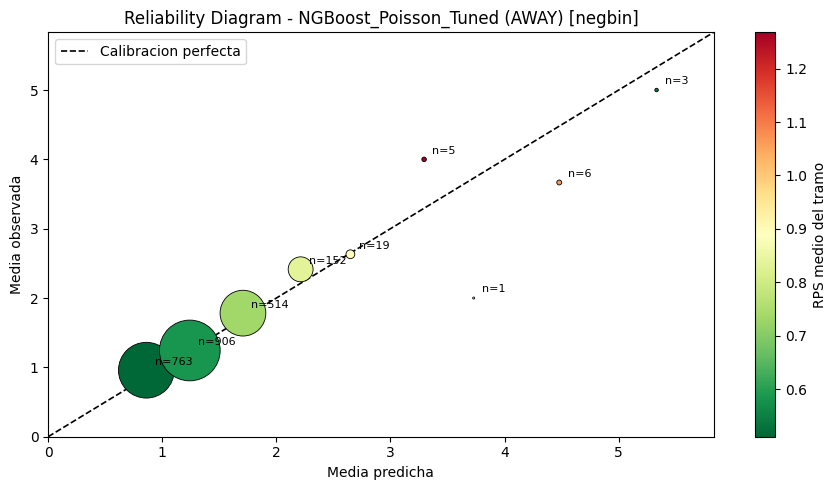


------------------------------------------------------------
  [2] Residuos por y_true - NGBoost_Poisson_Tuned | AWAY
------------------------------------------------------------
y_true   n  residual_mean  ci_low  ci_high
     0 651        -1.1450 -1.1723  -1.1202
     1 793        -0.2499 -0.2791  -0.2208
     2 531         0.6449  0.6080   0.6834
     3 251         1.4771  1.4069   1.5435
     4  91         2.2965  2.1776   2.4072
     5  36         2.8039  2.4184   3.1374
    6+  16         3.9412  3.4698   4.3712


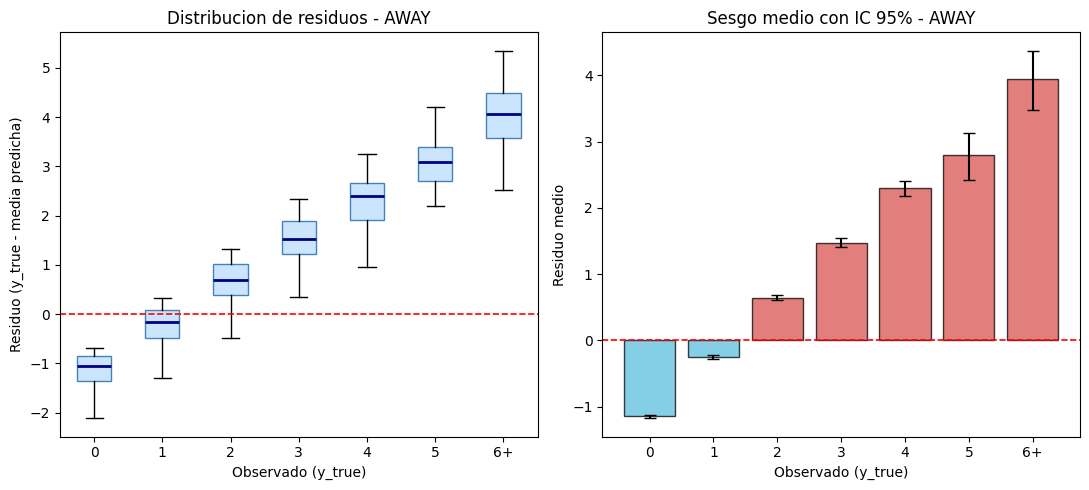


------------------------------------------------------------
  [3] Cola RPS > p95 - NGBoost_Poisson_Tuned | AWAY
------------------------------------------------------------
  Umbral RPS p95 : 1.67272
  En la cola          : 119 (5.0%)

grupo    n  rps_mean  ytrue_mean  pred_mean  residual_mean
 cola  119    2.2887      4.3529     1.5012         2.8518
resto 2250    0.5259      1.2147     1.3021        -0.0874


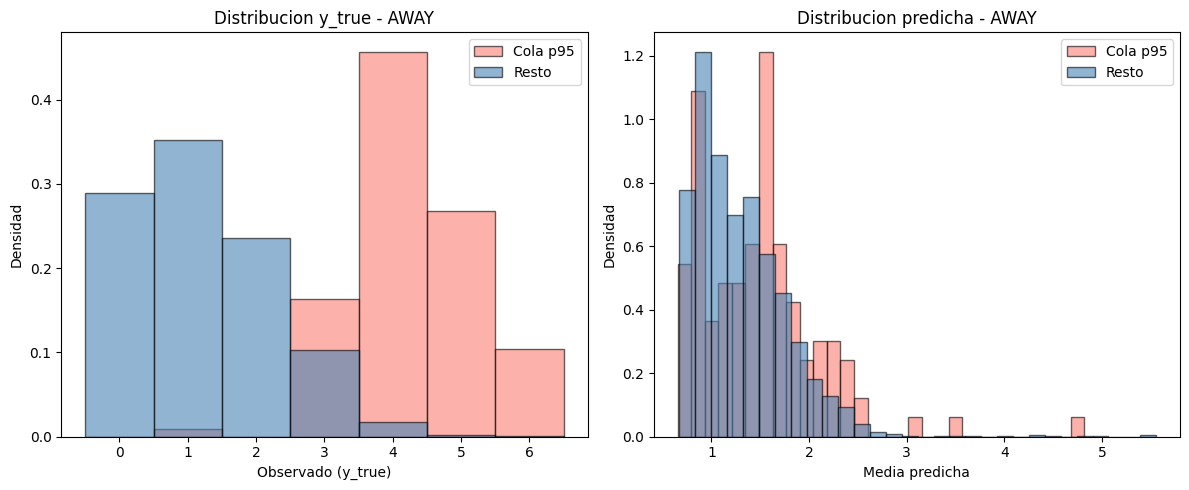


------------------------------------------------------------
  [4] Sesgo por 'tournament' - NGBoost_Poisson_Tuned | AWAY
------------------------------------------------------------
           tournament   n  rps_mean  residual_mean  ytrue_mean  pred_mean
      coupe_de_france 149  0.895511       0.320839    2.033557   1.712718
uefa-champions-league 189  0.668972       0.074295    1.412698   1.338403
           bundesliga 306  0.659672       0.164353    1.500000   1.335647
       premier-league 380  0.597104       0.058681    1.421053   1.362371
              ligue-1 306  0.592398       0.080856    1.369281   1.288425
   uefa-europa-league 189  0.558631      -0.059524    1.185185   1.244710
              serie-a 380  0.551747      -0.010548    1.221053   1.231601
               laliga 380  0.529088      -0.059393    1.165789   1.225182


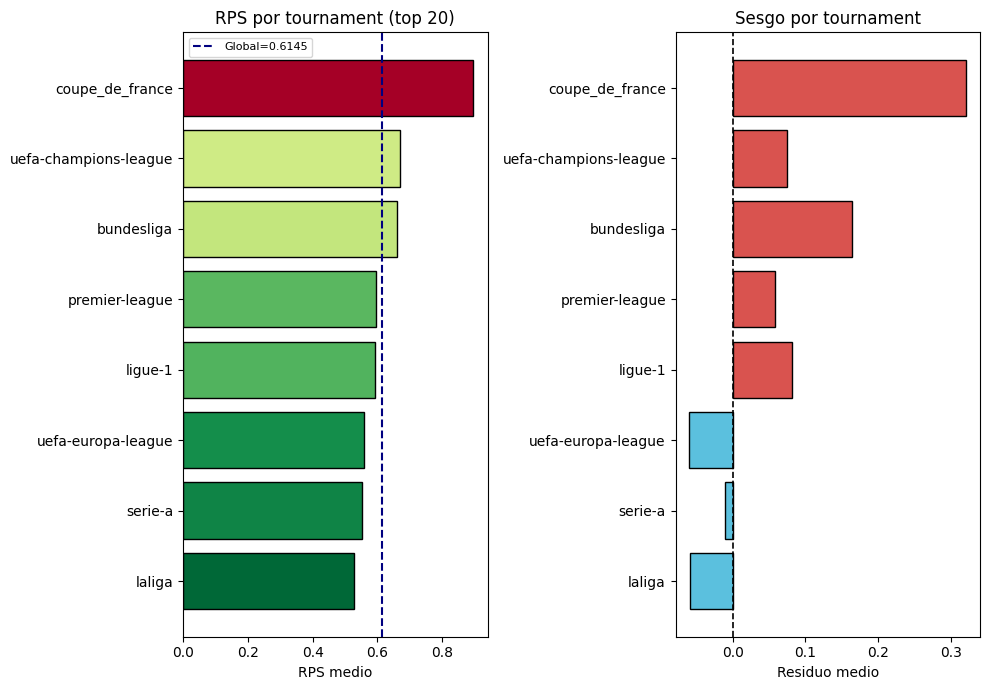


------------------------------------------------------------
  [5] Drift temporal - NGBoost_Poisson_Tuned | AWAY
------------------------------------------------------------
  [SKIP] Ninguna columna temporal disponible: ['year_month', 'matchweek', 'date', 'match_date', 'season_week']

------------------------------------------------------------
  [alpha] Sobredispersion - NGBoost_Poisson_Tuned | AWAY
------------------------------------------------------------
  alpha mean    : 0.1096
  alpha median  : 0.1089
  alpha p05/p95 : 0.0814 / 0.1369
  Var(Pearson)  : 0.9064   <- ~1 si NB ajusta bien
  Diagnostico   : dispersion razonable


In [26]:
META_VAL = ['match_datetime_utc', 'tournament']
meta_val_away = df_cleaned.loc[X_val_away.index, META_VAL].reset_index(drop=True)
analyzer_away = DistributionErrorAnalyzer(
    params     = results_nb["NGBoost"]["params"]["away"],   # ver nota abajo
    y_true     = y_val_away["away_score_90"].values,
    family     = "negbin",
    meta       = meta_val_away,          # opcional: league, fecha, etc.
    component  = "away",
    model_name = "NGBoost_Poisson_Tuned",
    config     = cfg,
)
analyzer_away.run_all()


  NGBoost_NegBin_Tuned [negbin] - HOME | N=2,369
  RPS mean=0.64605  |  media predicha=1.6073

------------------------------------------------------------
  [1] Calibracion - NGBoost_NegBin_Tuned | HOME
------------------------------------------------------------
  pred_bin    n  pred_mean  ytrue_mean  rps_mean
[0.5, 1.0)  216   0.921332    0.796296  0.462227
[1.0, 1.5) 1019   1.235875    1.211973  0.585717
[1.5, 2.0)  603   1.721381    1.600332  0.672929
[2.0, 2.5)  336   2.237950    2.181548  0.778433
[2.5, 3.0)  148   2.723585    2.655405  0.835575
[3.0, 3.5)   36   3.170354    2.944444  0.848271
[3.5, 4.0)    9   3.743665    3.000000  1.064572
[4.0, 5.0)    2   4.283556    2.500000  1.351841


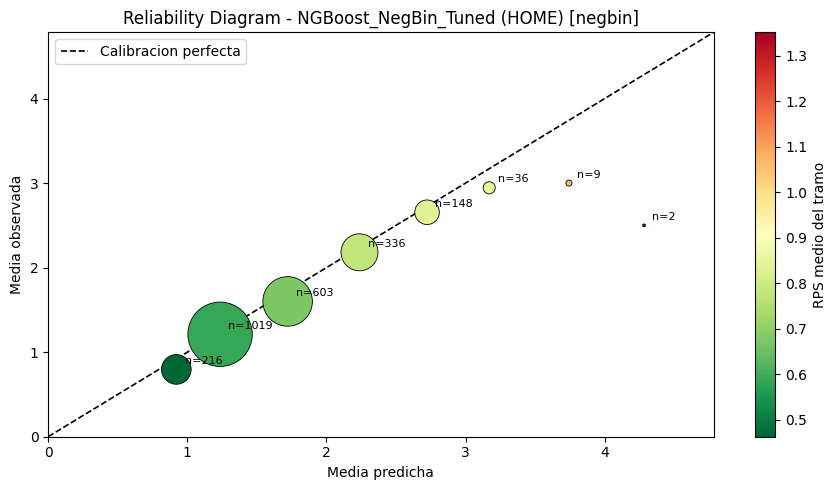


------------------------------------------------------------
  [2] Residuos por y_true - NGBoost_NegBin_Tuned | HOME
------------------------------------------------------------
y_true   n  residual_mean  ci_low  ci_high
     0 561        -1.3455 -1.3784  -1.3115
     1 771        -0.5195 -0.5556  -0.4839
     2 551         0.3354  0.2892   0.3802
     3 281         1.0854  1.0133   1.1570
     4 139         2.0125  1.9095   2.1109
     5  45         2.7470  2.5884   2.9034
    6+  21         4.3073  3.9386   4.6959


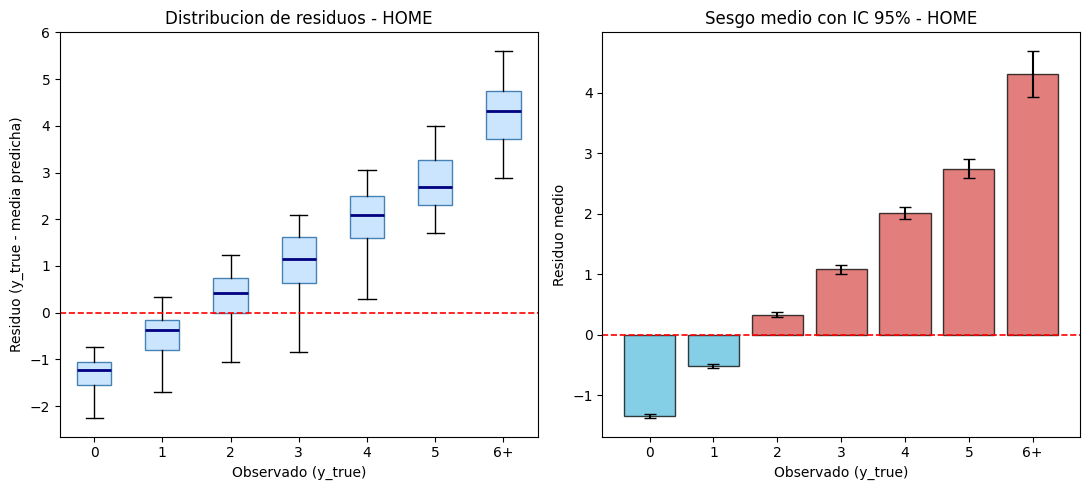


------------------------------------------------------------
  [3] Cola RPS > p95 - NGBoost_NegBin_Tuned | HOME
------------------------------------------------------------
  Umbral RPS p95 : 1.59854
  En la cola          : 119 (5.0%)

grupo    n  rps_mean  ytrue_mean  pred_mean  residual_mean
 cola  119    2.3013      4.4202     1.8362          2.584
resto 2250    0.5585      1.3822     1.5952         -0.213


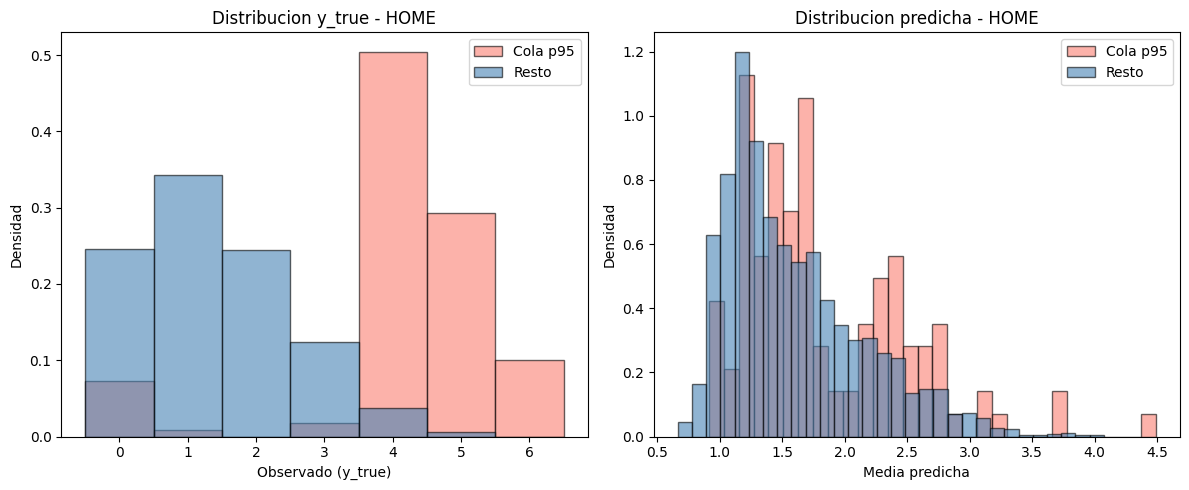


------------------------------------------------------------
  [4] Sesgo por 'tournament' - NGBoost_NegBin_Tuned | HOME
------------------------------------------------------------
           tournament   n  rps_mean  residual_mean  ytrue_mean  pred_mean
uefa-champions-league 189  0.747738       0.166776    1.841270   1.674494
      coupe_de_france 149  0.698920      -0.276466    1.120805   1.397271
           bundesliga 306  0.685581      -0.051475    1.633987   1.685462
              ligue-1 306  0.663034      -0.002366    1.607843   1.610209
       premier-league 380  0.649321      -0.182000    1.513158   1.695158
   uefa-europa-league 189  0.645844       0.121625    1.666667   1.545042
               laliga 380  0.577373      -0.102932    1.452632   1.555564
              serie-a 380  0.555190      -0.202770    1.339474   1.542244


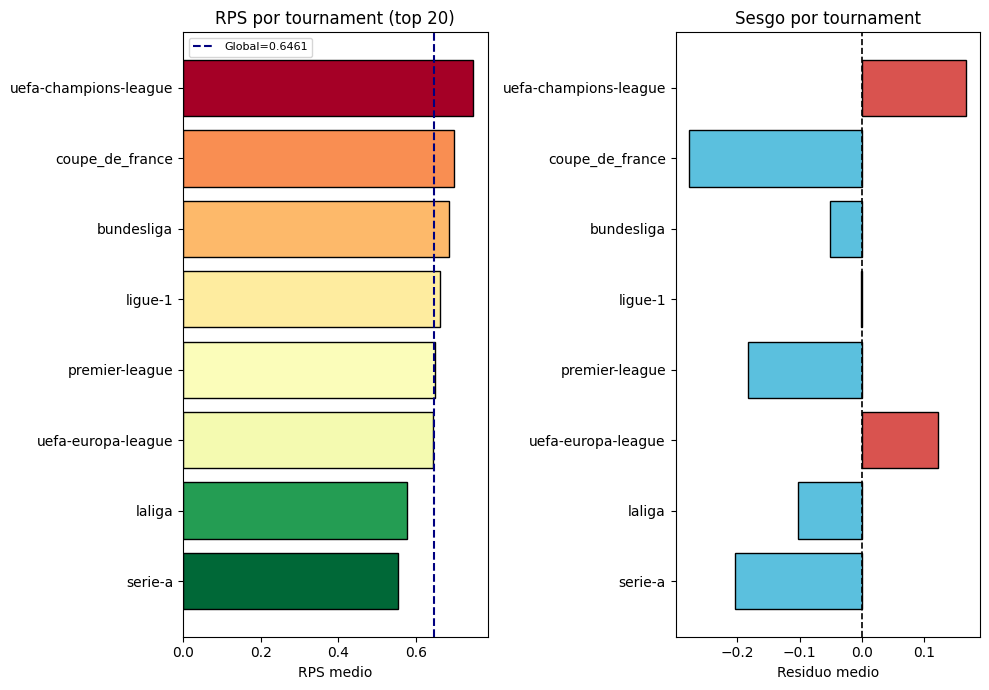


------------------------------------------------------------
  [5] Drift temporal - NGBoost_NegBin_Tuned | HOME
------------------------------------------------------------
  [SKIP] Ninguna columna temporal disponible: ['year_month', 'matchweek', 'date', 'match_date', 'season_week']

------------------------------------------------------------
  [alpha] Sobredispersion - NGBoost_NegBin_Tuned | HOME
------------------------------------------------------------
  alpha mean    : 0.0932
  alpha median  : 0.0938
  alpha p05/p95 : 0.0681 / 0.1174
  Var(Pearson)  : 0.8184   <- ~1 si NB ajusta bien
  Diagnostico   : dispersion razonable

------------------------------------------------------------
  [alpha] Sobredispersion - NGBoost_NegBin_Tuned | HOME
------------------------------------------------------------
  alpha mean    : 0.0932
  alpha median  : 0.0938
  alpha p05/p95 : 0.0681 / 0.1174
  Var(Pearson)  : 0.8184   <- ~1 si NB ajusta bien
  Diagnostico   : dispersion razonable


{'alpha_mean': 0.09316305996697628,
 'alpha_median': 0.09382508954780819,
 'pearson_var': 0.8183559289874526}

In [23]:
from src.error_analysis.distribution_error_analysis import DistributionErrorAnalyzer
META_VAL = ['match_datetime_utc', 'tournament']
meta_val_home = df_cleaned.loc[X_val_home.index, META_VAL].reset_index(drop=True)

analyzer_home = DistributionErrorAnalyzer(
    params     = results_nb["NGBoost"]["params"]["home"],   # ver nota abajo
    y_true     = y_val_home["home_score_90"].values,
    family     = "negbin",
    meta       = meta_val_home,          # opcional: league, fecha, etc.
    component  = "home",
    model_name = "NGBoost_NegBin_Tuned",
    config     = cfg,
)

analyzer_home.run_all()
analyzer_home.summarize_dispersion()    # solo NegBin: contrasta alpha vs residuos de Pearson


  NGBoost_NegBin_Tuned [negbin] - AWAY | N=2,369
  RPS mean=0.61445  |  media predicha=1.3121

------------------------------------------------------------
  [1] Calibracion - NGBoost_NegBin_Tuned | AWAY
------------------------------------------------------------
   pred_bin   n  pred_mean  ytrue_mean  rps_mean
 [0.5, 1.0) 763   0.860463    0.959371  0.511481
 [1.0, 1.5) 906   1.241280    1.243929  0.582637
 [1.5, 2.0) 514   1.707164    1.782101  0.735783
 [2.0, 2.5) 152   2.212706    2.414474  0.836146
 [2.5, 3.0)  19   2.648666    2.631579  0.893581
 [3.0, 3.5)   5   3.294606    4.000000  1.267738
 [3.5, 4.0)   1   3.729053    2.000000  0.894849
 [4.0, 5.0)   6   4.478982    3.666667  1.068031
[5.0, +inf)   3   5.331998    5.000000  0.536083


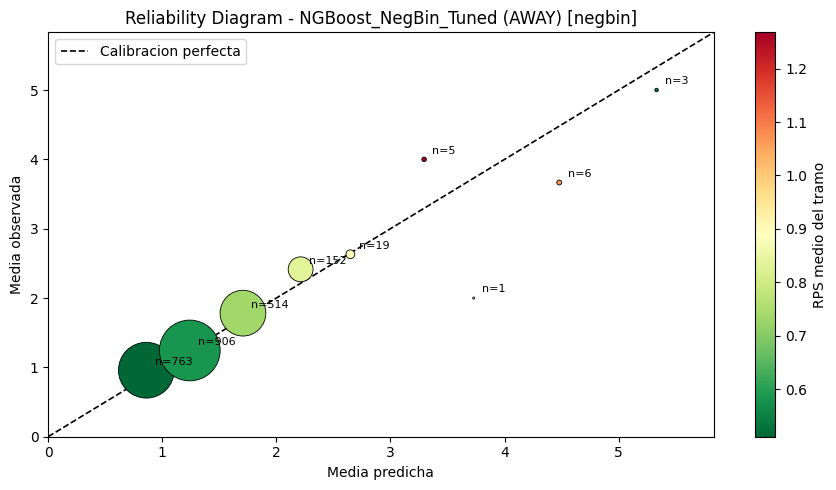


------------------------------------------------------------
  [2] Residuos por y_true - NGBoost_NegBin_Tuned | AWAY
------------------------------------------------------------
y_true   n  residual_mean  ci_low  ci_high
     0 651        -1.1450 -1.1723  -1.1202
     1 793        -0.2499 -0.2791  -0.2208
     2 531         0.6449  0.6080   0.6834
     3 251         1.4771  1.4069   1.5435
     4  91         2.2965  2.1776   2.4072
     5  36         2.8039  2.4184   3.1374
    6+  16         3.9412  3.4698   4.3712


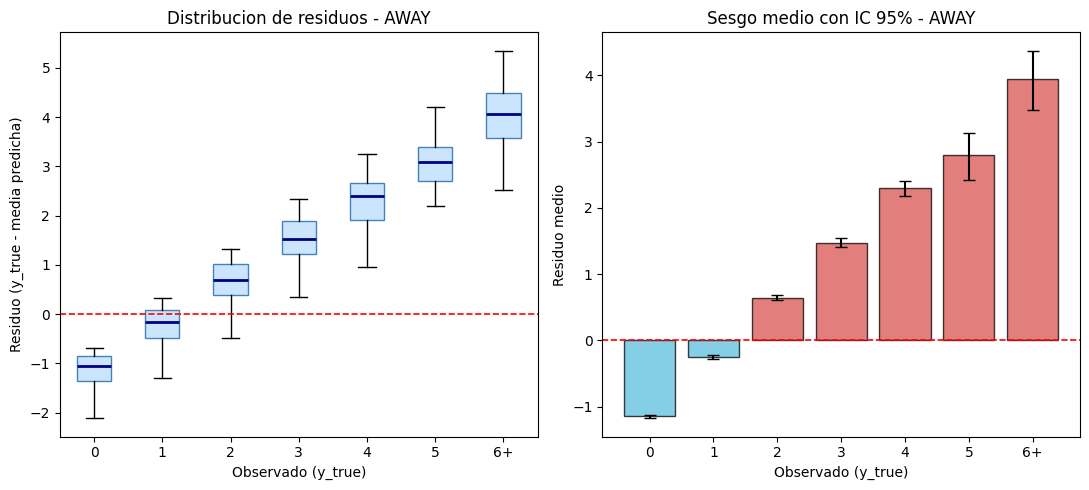


------------------------------------------------------------
  [3] Cola RPS > p95 - NGBoost_NegBin_Tuned | AWAY
------------------------------------------------------------
  Umbral RPS p95 : 1.67272
  En la cola          : 119 (5.0%)

grupo    n  rps_mean  ytrue_mean  pred_mean  residual_mean
 cola  119    2.2887      4.3529     1.5012         2.8518
resto 2250    0.5259      1.2147     1.3021        -0.0874


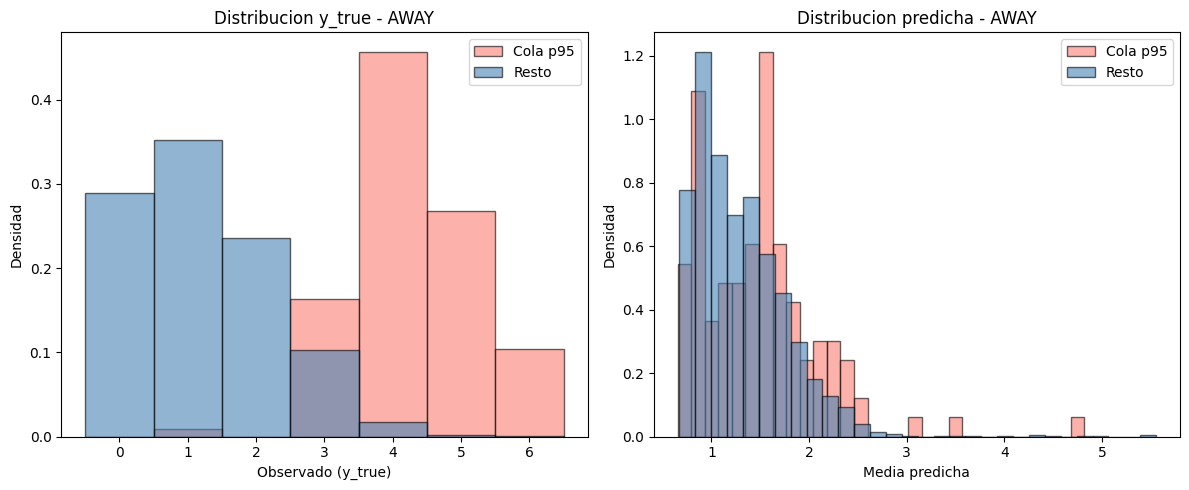


------------------------------------------------------------
  [4] Sesgo por 'tournament' - NGBoost_NegBin_Tuned | AWAY
------------------------------------------------------------
           tournament   n  rps_mean  residual_mean  ytrue_mean  pred_mean
      coupe_de_france 149  0.895511       0.320839    2.033557   1.712718
uefa-champions-league 189  0.668972       0.074295    1.412698   1.338403
           bundesliga 306  0.659672       0.164353    1.500000   1.335647
       premier-league 380  0.597104       0.058681    1.421053   1.362371
              ligue-1 306  0.592398       0.080856    1.369281   1.288425
   uefa-europa-league 189  0.558631      -0.059524    1.185185   1.244710
              serie-a 380  0.551747      -0.010548    1.221053   1.231601
               laliga 380  0.529088      -0.059393    1.165789   1.225182


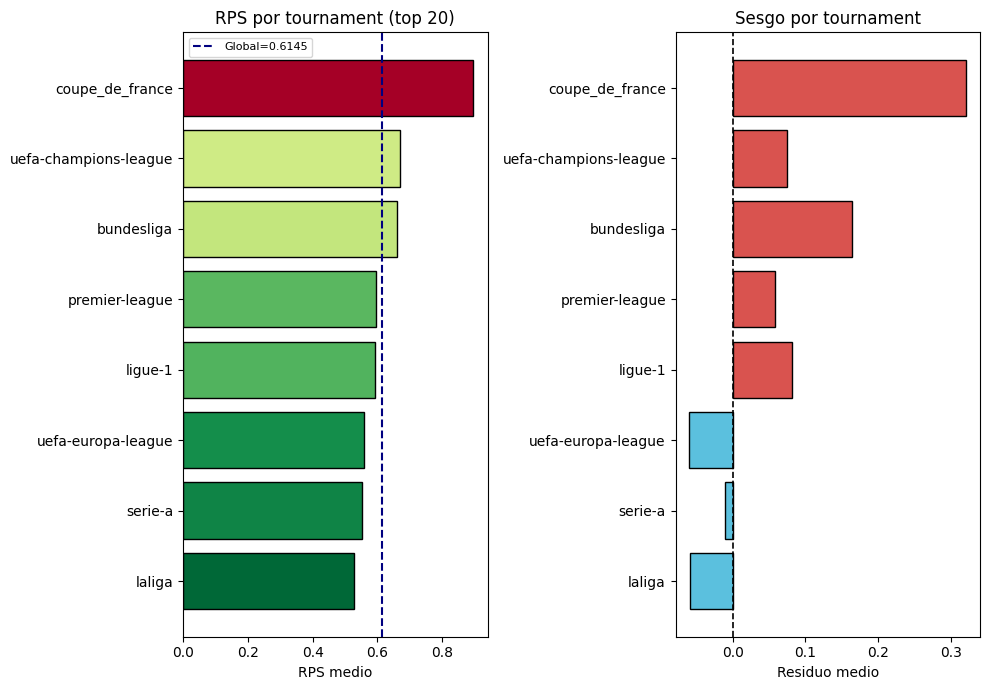


------------------------------------------------------------
  [5] Drift temporal - NGBoost_NegBin_Tuned | AWAY
------------------------------------------------------------
  [SKIP] Ninguna columna temporal disponible: ['year_month', 'matchweek', 'date', 'match_date', 'season_week']

------------------------------------------------------------
  [alpha] Sobredispersion - NGBoost_NegBin_Tuned | AWAY
------------------------------------------------------------
  alpha mean    : 0.1096
  alpha median  : 0.1089
  alpha p05/p95 : 0.0814 / 0.1369
  Var(Pearson)  : 0.9064   <- ~1 si NB ajusta bien
  Diagnostico   : dispersion razonable


In [24]:
META_VAL = ['match_datetime_utc', 'tournament']
meta_val_away = df_cleaned.loc[X_val_away.index, META_VAL].reset_index(drop=True)
analyzer_away = DistributionErrorAnalyzer(
    params     = results_nb["NGBoost"]["params"]["away"],   # ver nota abajo
    y_true     = y_val_away["away_score_90"].values,
    family     = "negbin",
    meta       = meta_val_away,          # opcional: league, fecha, etc.
    component  = "away",
    model_name = "NGBoost_NegBin_Tuned",
    config     = cfg,
)
analyzer_away.run_all()


------------------------------------------------------------
  [6] Correlacion de error HOME vs AWAY | NGBoost_NegBin_Tuned
------------------------------------------------------------
  N observaciones    : 2,369
  Spearman rho (RPS) : -0.0462  p=2.4552e-02
  Spearman rho (res) : -0.0145  p=4.7975e-01
  Spearman rho (log) : -0.0137  p=5.0403e-01

  Interpretacion: Correlacion baja: los componentes fallan de forma independiente.


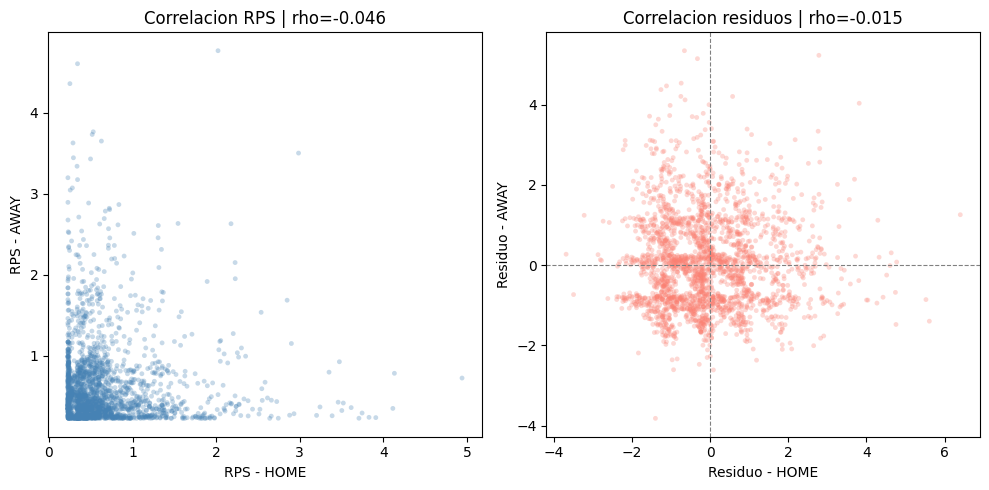

{'rho_rps': -0.046193747406248965,
 'p_rps': 0.02455241908715871,
 'rho_residual': -0.014526548081073344,
 'p_residual': 0.47974938148927926,
 'rho_log': -0.013734198913163905,
 'p_log': 0.5040348022001102}

In [27]:
DistributionErrorAnalyzer.correlation_between(analyzer_home, analyzer_away)

### Test Evaluation Poisson

In [28]:
X_te = {"home": X_test_home, "away": X_test_away}
y_te = {"home": y_test_home["home_score_90"], "away": y_test_away["away_score_90"]}

summary_test, results_test = evaluate_on_validation(
    cfg, X_tr, y_tr, X_va, y_va, feats,   # val sigue siendo el early stopping
    models      = ["NGBoost"],
    family      = "poisson",
    best_params = best,
    X_eval      = X_te,                    # las metricas salen de aca
    y_eval      = y_te,
)

print(summary_test.to_string(index=False))

save_evaluation(results_test["NGBoost"], "test_ngboost_poisson_results", cfg,
                metadata={"split": "test", "label": "NGBoost_Poisson_Tuned"},
                metrics_dir=MODELS_DIR)

--- Entrenando NGBoost | home [poisson] ---
--- Entrenando NGBoost | away [poisson] ---

  FULL EVALUATION - NGBoost | poisson [poisson]

--------------------------------------------------
  RPS Report - NGBoost | poisson | home [poisson]
--------------------------------------------------
  N observaciones : 2596
  RPS mean        : 0.69785   <- principal
  RPS std         : 0.63175
  RPS median      : 0.50143
  RPS p95         : 1.87705   <- cola
--------------------------------------------------

--------------------------------------------------
  RPS Report - NGBoost | poisson | away [poisson]
--------------------------------------------------
  N observaciones : 2596
  RPS mean        : 0.63195   <- principal
  RPS std         : 0.65513
  RPS median      : 0.41784
  RPS p95         : 1.78046   <- cola
--------------------------------------------------

--------------------------------------------------
  NLL Report - NGBoost | poisson | home [poisson]
-----------------------------

WindowsPath('c:/Users/javie/OneDrive/Escritorio/ModelosProbabilisticos/EnvOficial/outputs/clubs/models/goals/test_ngboost_poisson_results.json')

### Test Evaluation NegBin

In [31]:
X_te = {"home": X_test_home, "away": X_test_away}
y_te = {"home": y_test_home["home_score_90"], "away": y_test_away["away_score_90"]}

summary_test, results_test = evaluate_on_validation(
    cfg, X_tr, y_tr, X_va, y_va, feats,   # val sigue siendo el early stopping
    models      = ["NGBoost"],
    family      = "negbin",
    best_params = best_nb,
    X_eval      = X_te,                    # las metricas salen de aca
    y_eval      = y_te,
)

print(summary_test.to_string(index=False))

save_evaluation(results_test["NGBoost"], "test_ngboost_negbin_results", cfg,
                metadata={"split": "test", "label": "NGBoost_Poisson_Tuned"},
                metrics_dir=MODELS_DIR)

--- Entrenando NGBoost | home [negbin] ---
--- Entrenando NGBoost | away [negbin] ---

  FULL EVALUATION - NGBoost | negbin [negbin]

--------------------------------------------------
  RPS Report - NGBoost | negbin | home [negbin]
--------------------------------------------------
  N observaciones : 2596
  RPS mean        : 0.69891   <- principal
  RPS std         : 0.61126
  RPS median      : 0.51284
  RPS p95         : 1.84987   <- cola
--------------------------------------------------

--------------------------------------------------
  RPS Report - NGBoost | negbin | away [negbin]
--------------------------------------------------
  N observaciones : 2596
  RPS mean        : 0.63160   <- principal
  RPS std         : 0.63617
  RPS median      : 0.42458
  RPS p95         : 1.73255   <- cola
--------------------------------------------------

--------------------------------------------------
  NLL Report - NGBoost | negbin | home [negbin]
---------------------------------------

WindowsPath('c:/Users/javie/OneDrive/Escritorio/ModelosProbabilisticos/EnvOficial/outputs/clubs/models/goals/test_ngboost_negbin_results.json')

# Result

In [33]:
from src.metrics.distribution_metrics import evaluate_from_config
from src.evaluation.persistence import save_evaluation
from src.evaluation.model_persistence import (
    build_bundle, save_bundle, predict_bundle, predict_distribution,
)
from src.evaluation.model_persistence import build_bundle, save_bundle

best_poisson = {
    "home": load_best_params("NGBoost", cfg, family="poisson",
                            component="home", params_only=True),
    "away": load_best_params("NGBoost", cfg, family="poisson",
                            component="away", params_only=True),
}

for comp, X_tr_c, y_tr_c, X_va_c, y_va_c, feats_c in [
    ("home", X_train_home, y_train_home["home_score_90"],
            X_val_home,   y_val_home["home_score_90"],   X_train_home.columns.to_list()),
    ("away", X_train_away, y_train_away["away_score_90"],
            X_val_away,   y_val_away["away_score_90"],   X_train_away.columns.to_list()),
]:
    model, _, imputer = train_and_predict(
        "NGBoost", "poisson",
        X_tr_c[feats_c], y_tr_c, X_va_c[feats_c], y_va_c,
        params={**cfg.model_params("NGBoost"), **best_poisson[comp]},
        fit_params=cfg.fit_params("NGBoost"),
        guards=cfg.numeric_guards,
        return_imputer=True,
    )
    bundle = build_bundle(
        model=model, model_name="NGBoost", family="poisson",
        component=comp, features=feats_c, config=cfg, imputer=imputer,
        best_params=best_poisson[comp],
        metrics={
            "test_rps": results_test["NGBoost"]["rps"][comp]["rps_mean"],
            "test_nll": results_test["NGBoost"]["nll"][comp],
            "test_n":   int(results_test["NGBoost"]["rps"][comp]["n_samples"]),
        },
    )
    save_bundle(bundle, cfg)


 [MODEL] ngboost_poisson_home_16 -> C:\Users\javie\OneDrive\Escritorio\ModelosProbabilisticos\EnvOficial\outputs\clubs\models\goals\ngboost_poisson_home_16.pkl  (1.3 MB)
 [MODEL] ngboost_poisson_away_16 -> C:\Users\javie\OneDrive\Escritorio\ModelosProbabilisticos\EnvOficial\outputs\clubs\models\goals\ngboost_poisson_away_16.pkl  (0.7 MB)
